In [81]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [82]:
df = pd.read_csv(r"E:\hackthon\Future of Jobs AI Dataset.csv")

In [83]:
df

,job_title,country,experience_level,education_level,year,salary,ai_risk_score,primary_skill,skill_demand_score,job_openings,job_survival_class,salary_bucket,ai_risk_category
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12338,Data Scientist,Germany,Entry,Master,2030,27079.49,0.40,Python,89,2395,1,High,Medium Risk
12339,Cybersecurity Analyst,USA,Mid,Bachelor,2028,42474.50,0.28,Security,73,24254,2,High,Low Risk
12340,Software Engineer,India,Senior,Master,2028,19381.43,0.48,Java,77,27356,1,Medium,Medium Risk
12341,AI Researcher,Australia,Entry,PhD,2023,32647.87,0.13,Deep Learning,78,48428,2,High,Low Risk


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           12343 non-null  object 
 1   country             12343 non-null  object 
 2   experience_level    12343 non-null  object 
 3   education_level     12343 non-null  object 
 4   year                12343 non-null  int64  
 5   salary              12343 non-null  float64
 6   ai_risk_score       12343 non-null  float64
 7   primary_skill       12343 non-null  object 
 8   skill_demand_score  12343 non-null  int64  
 9   job_openings        12343 non-null  int64  
 10  job_survival_class  12343 non-null  int64  
 11  salary_bucket       12343 non-null  object 
 12  ai_risk_category    12343 non-null  object 
dtypes: float64(2), int64(4), object(7)
memory usage: 1.2+ MB


In [85]:
df.describe()

,year,salary,ai_risk_score,skill_demand_score,job_openings,job_survival_class
count,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000
mean,2025.054525,34553.729166,0.396008,79.453374,25223.652029,1.310054
std,6.058714,18024.702961,0.187665,11.483535,14163.309081,0.658417
min,2015.000000,3875.170000,0.050000,60.000000,1002.000000,0.000000
25%,2020.000000,21331.405000,0.260000,70.000000,12993.000000,1.000000
50%,2025.000000,31573.380000,0.360000,79.000000,24896.000000,1.000000
75%,2030.000000,45307.845000,0.490000,89.000000,37440.500000,2.000000
max,2035.000000,113589.260000,0.850000,99.000000,49998.000000,2.000000


In [86]:
df.isna().sum()

job_title             0
country               0
experience_level      0
education_level       0
year                  0
salary                0
ai_risk_score         0
primary_skill         0
skill_demand_score    0
job_openings          0
job_survival_class    0
salary_bucket         0
ai_risk_category      0
dtype: int64

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df['education_level'].value_counts()

education_level
Master      4146
PhD         4104
Bachelor    4093
Name: count, dtype: int64

In [89]:
nos_col = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_col = df.select_dtypes(include=['object']).columns.tolist()

In [90]:
nos_col

['year',
 'salary',
 'ai_risk_score',
 'skill_demand_score',
 'job_openings',
 'job_survival_class']

In [91]:
cat_col

['job_title',
 'country',
 'experience_level',
 'education_level',
 'primary_skill',
 'salary_bucket',
 'ai_risk_category']

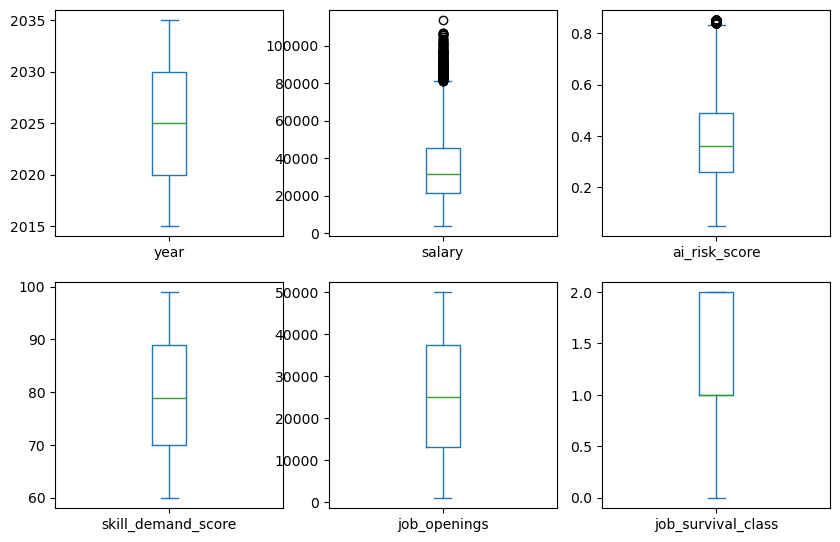

In [92]:
df[nos_col].plot(kind='box',subplots=True,layout=(3,3),figsize=(10,10))
plt.show()

In [93]:
df.skew(numeric_only=True)

year                 -0.002089
salary                0.783204
ai_risk_score         0.649878
skill_demand_score    0.011053
job_openings          0.043731
job_survival_class   -0.430881
dtype: float64

In [94]:
df['job_title'].value_counts()

job_title
Business Analyst         1312
Data Analyst             1293
Cloud Engineer           1273
Software Engineer        1252
Product Manager          1247
Data Scientist           1225
Cybersecurity Analyst    1209
AI Researcher            1209
ML Engineer              1205
DevOps Engineer          1118
Name: count, dtype: int64

In [95]:
df['ai_risk_score'].value_counts()

ai_risk_score
0.35    435
0.33    353
0.32    350
0.30    335
0.34    333
       ... 
0.12     50
0.54     50
0.08     50
0.79     45
0.14     39
Name: count, Length: 81, dtype: int64

In [96]:
## Cat vs tar

In [97]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    if col != 'ai_risk_category':
        ct = pd.crosstab(df[col], df['ai_risk_category'])
        
        chi2, p, _, _ = chi2_contingency(ct)
        
        n = ct.sum().sum()
        phi2 = chi2 / n
        r, k = ct.shape
        cramers_v = np.sqrt(phi2 / min(k-1, r-1))
        
        print(f"{col} → p-value: {p:.5f}, Cramer's V: {cramers_v:.3f}")

job_title → p-value: 0.00000, Cramer's V: 0.822
country → p-value: 0.46250, Cramer's V: 0.020
experience_level → p-value: 0.75038, Cramer's V: 0.009
education_level → p-value: 0.32399, Cramer's V: 0.014
primary_skill → p-value: 0.00000, Cramer's V: 0.805
salary_bucket → p-value: 0.00000, Cramer's V: 0.181


In [98]:
df = df.drop(['country','experience_level','education_level'],axis=1)

## Drop
- "Country shows almost no relationship with AI risk (very low Cramér’s V), so it doesn’t help prediction
- "Experience level has negligible impact on AI risk, making it an uninformative feature."
- "Education level does not significantly influence AI risk categories, so it adds no value to the model."

In [99]:
df['ai_risk_category'].value_counts()

ai_risk_category
Medium Risk    6016
Low Risk       4033
High Risk      2294
Name: count, dtype: int64

In [100]:
df['ai_risk_category'] = df['ai_risk_category'].map({
    'Low Risk': 0,
    'Medium Risk': 1,
    'High Risk':2
    
})

<Axes: >

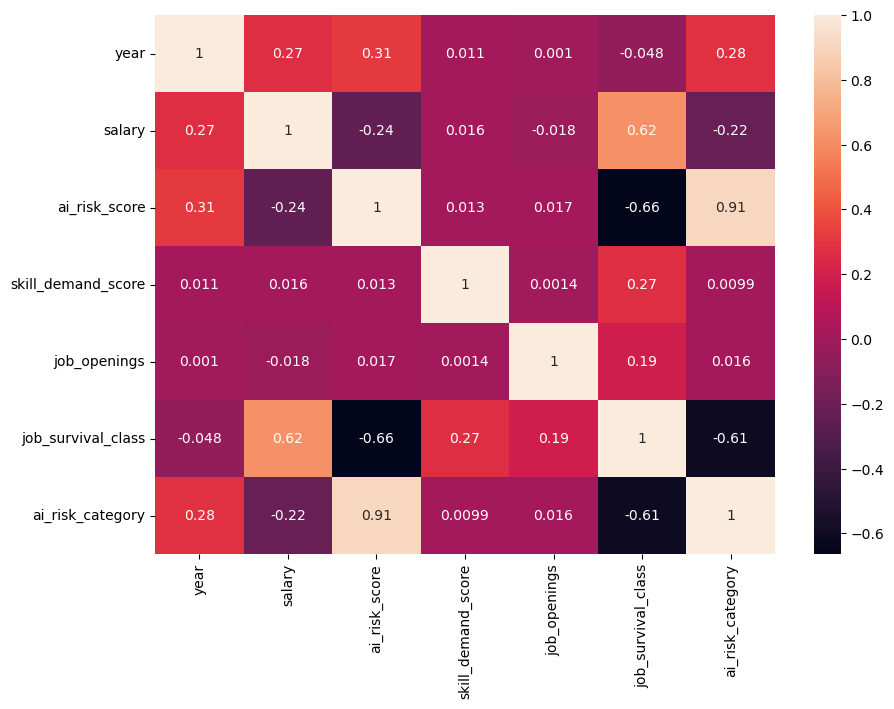

In [101]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [103]:
df.groupby('primary_skill')['skill_demand_score'].mean().sort_values(ascending=False)

primary_skill
Java             79.880192
Excel            79.769817
Deep Learning    79.568238
Strategy         79.554932
Docker           79.497317
AWS              79.487824
SQL              79.426914
Python           79.224280
Security         78.860215
Name: skill_demand_score, dtype: float64

In [18]:
corr = df.corr(numeric_only=True)
print(corr['ai_risk_category'].sort_values(ascending=False))

ai_risk_category      1.000000
ai_risk_score         0.914453
year                  0.283504
job_openings          0.015726
skill_demand_score    0.009894
salary               -0.218045
job_survival_class   -0.607208
Name: ai_risk_category, dtype: float64


In [104]:
df = df.drop(['ai_risk_score', 'job_survival_class', 'job_openings', 'skill_demand_score','year'],axis = 1)

## Drop
`ai_risk_score` ="Highly correlated with the target variable (~0.91), leading to data leakage and redundant information."

`job_survival_class` ="Strongly related to the target (~-0.60), providing overlapping information and reducing model generalization."

`job_openings` ="Shows negligible correlation with the target (~0.01), so it does not contribute to prediction."

`skill_demand_score` ="Has almost no correlation with the target and shows minimal variation across skills, making it uninformative."

`year`= "Provides limited predictive value and was removed to simplify the model and reduce noise."

In [105]:
cat_col

['job_title',
 'country',
 'experience_level',
 'education_level',
 'primary_skill',
 'salary_bucket',
 'ai_risk_category']

In [106]:
x = df.drop(['ai_risk_category'],axis=1)
y= df['ai_risk_category']

In [107]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [108]:
num_cal = x.select_dtypes(include=['int64','float64']).columns
cat_col1 = x.select_dtypes(include=['object']).columns

In [110]:
for i in cat_col1:
    print(i,x[i].unique())

job_title ['Data Scientist' 'Software Engineer' 'Data Analyst' 'DevOps Engineer'
 'Cybersecurity Analyst' 'Cloud Engineer' 'Business Analyst'
 'AI Researcher' 'ML Engineer' 'Product Manager']
primary_skill ['Python' 'Java' 'SQL' 'Docker' 'Security' 'AWS' 'Excel' 'Deep Learning'
 'Strategy']
salary_bucket ['High' 'Medium' 'Low']


In [111]:
cat_col1 

Index(['job_title', 'primary_skill', 'salary_bucket'], dtype='object')

In [116]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [117]:
ordinal_cols = ['salary_bucket']
nominal_cols = ['job_title','primary_skill']

In [118]:
nos_pipeline = Pipeline([
    ('scaler' , StandardScaler())
])

ord_pipline = Pipeline([
    ('ord',OrdinalEncoder(categories=[ ['Low','Medium','High']]))
])

nom_pipline = Pipeline([
    ('nom',OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))
])

In [119]:
preprocessor = ColumnTransformer([
    ('num',nos_pipeline,num_cal),
    ('ord',ord_pipline,ordinal_cols),
    ('nom',nom_pipline,nominal_cols)
])

<Axes: xlabel='ai_risk_category', ylabel='count'>

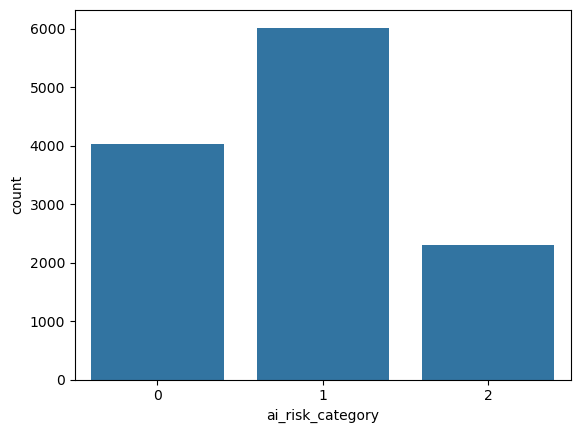

In [120]:
sns.countplot(x='ai_risk_category',data =df)

In [121]:
df['ai_risk_category'].value_counts(normalize=True)*100

ai_risk_category
1    48.740177
0    32.674390
2    18.585433
Name: proportion, dtype: float64

## model sel

In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score,StratifiedKFold

models = {
    'RandomForestClassifier' : RandomForestClassifier(),
    'DecisionTreeClassifier' : DecisionTreeClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'XGBClassifier' : XGBClassifier(),
    'GradientBoostingClassifier' : GradientBoostingClassifier(),
    'SVC':SVC(probability=True),
    'LogisticRegression' :LogisticRegression(max_iter=1000)
}
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)


for name ,model in models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model',model)
    ])

    score = cross_val_score(pipeline,x_train,y_train,cv=cv,scoring='f1_weighted',n_jobs=-1)
    print(f'{name}f1 score :{score.mean()}')

RandomForestClassifierf1 score :0.8001097030901441
DecisionTreeClassifierf1 score :0.799811547584605
KNeighborsClassifierf1 score :0.8307011728113878
XGBClassifierf1 score :0.8378608550796873
GradientBoostingClassifierf1 score :0.8460375524882316
SVCf1 score :0.8380190588316291
LogisticRegressionf1 score :0.840054432557831


## best 3 models
- LogisticRegression
- GradientBoostingClassifier()
- SVC()

In [38]:
## Model Evaluation and overfitting chek 

In [124]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

top_models = {
    'LogisticRegression': LogisticRegression(),
    'GradientBoosting': GradientBoostingClassifier(),
    'SVC': SVC()
}

for name, model in top_models.items():
    print(f"\n Model: {name}")
    
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(x_train, y_train)
    
    # Prediction
    y_pred = pipeline.predict(x_test)
    
    # Evaluation
    print("Accuracy:", accuracy_score(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Overfitting check
    train_score = pipeline.score(x_train, y_train)
    test_score = pipeline.score(x_test, y_test)
    
    print("\nTrain Score:", train_score)
    print("Test Score:", test_score)


 Model: LogisticRegression
Accuracy: 0.8262454434993924

Confusion Matrix:
[[665 174   0]
 [183 952  72]
 [  0   0 423]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.79       839
           1       0.85      0.79      0.82      1207
           2       0.85      1.00      0.92       423

    accuracy                           0.83      2469
   macro avg       0.83      0.86      0.84      2469
weighted avg       0.83      0.83      0.82      2469


Train Score: 0.8418067652420498
Test Score: 0.8262454434993924

 Model: GradientBoosting
Accuracy: 0.8367760226812475

Confusion Matrix:
[[669 170   0]
 [169 980  58]
 [  0   6 417]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       839
           1       0.85      0.81      0.83      1207
           2       0.88      0.99      0.93       423

    accuracy                           0.84    

## Rusult
- 3 model good

## GradientBoosting Hyperparameter Tuning and Overfitting Check

In [132]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

# pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', GradientBoostingClassifier())
])

# parameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__subsample': [0.8, 1.0],
    'model__max_features': ['sqrt', 'log2', None]
}

# randomized search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# train
random_search.fit(x_train, y_train)

# best model
best_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# =========================
# Evaluation + Overfitting Check
# =========================

# prediction
y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# F1 score (train vs test)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nTrain F1:", round(train_f1))
print("Test F1:", round(test_f1))
print("Gap:", round(train_f1 - test_f1))

# final decision
if train_f1 - test_f1 > 0.05:
    print("\nyes over fit")
else:
    print("\n Model balanced ")

Best Parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 5, 'model__learning_rate': 0.05}
Best CV Score: 0.8473193293226963

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.81      0.80       839
           1       0.85      0.82      0.83      1207
           2       0.89      0.98      0.93       423

    accuracy                           0.84      2469
   macro avg       0.85      0.87      0.86      2469
weighted avg       0.84      0.84      0.84      2469


Train F1: 1
Test F1: 1
Gap: 0

 Model balanced 


## SVM + Overfitting Check

In [127]:
from sklearn.svm import SVC

# pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SVC(probability=True))
])

# parameter grid
param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf', 'poly'],
    'model__gamma': ['scale', 'auto'],
    'model__degree': [2, 3, 4]   # only for poly kernel
}

# randomized search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# train
random_search.fit(x_train, y_train)

# best model
best_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# =========================
# Evaluation + Overfitting Check
# =========================

# prediction
y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# F1 score (train vs test)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nTrain F1:", round(train_f1,4))
print("Test F1:", round(test_f1,4))
print("Gap:", round(train_f1 - test_f1,4))

# final decision
if train_f1 - test_f1 > 0.05:
    print("\nYes overfit")
else:
    print("\nModel balanced ahe")

Best Parameters: {'model__kernel': 'rbf', 'model__gamma': 'scale', 'model__degree': 4, 'model__C': 1}
Best CV Score: 0.8373980148401803

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.79      0.79       839
           1       0.84      0.79      0.82      1207
           2       0.85      1.00      0.92       423

    accuracy                           0.83      2469
   macro avg       0.83      0.86      0.84      2469
weighted avg       0.83      0.83      0.82      2469


Train F1: 0.8378
Test F1: 0.8239
Gap: 0.0139

Model balanced ahe


## LogisticRegression + Hyperparameter Tuning and Overfitting Check

In [128]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# parameter grid
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],   # safe option
    'model__solver': ['lbfgs', 'liblinear']
}

# randomized search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# train
random_search.fit(x_train, y_train)

# best model
best_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# =========================
# Evaluation + Overfitting Check
# =========================

# prediction
y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# F1 score (train vs test)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nTrain F1:", round(train_f1,4))
print("Test F1:", round(test_f1,4))
print("Gap:", round(train_f1 - test_f1,4))

# final decision
if train_f1 - test_f1 > 0.05:
    print("\nYes overfit")
else:
    print("\nModel balanced ahe")

Best Parameters: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 100}
Best CV Score: 0.8400428175783672

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.79      0.79       839
           1       0.84      0.79      0.82      1207
           2       0.85      1.00      0.92       423

    accuracy                           0.83      2469
   macro avg       0.83      0.86      0.84      2469
weighted avg       0.83      0.83      0.82      2469


Train F1: 0.841
Test F1: 0.8239
Gap: 0.017

Model balanced ahe


In [135]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# probabilities
y_prob = best_model.predict_proba(x_test)

# convert target to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

# ROC AUC score
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9588919636381789


## save csv

In [136]:
df.to_csv("final_dataset mlhackathon.csv", index=False)

## save model

In [137]:
import joblib

joblib.dump(best_model, "final_model.pkl")

['final_model.pkl']

## 3. Feature Selection (MOST IMPORTANT )
-"We performed statistical analysis using Chi-square and Cramér’s V for categorical features and correlation for numerical features."

## 4. Preprocessing
- "We used OneHot Encoding for categorical variables to convert them into numerical format."

## 5. Model Building
- multiple models try kele:

Logistic Regression
SVM
Random Forest
Gradient Boosting

👉
"We compared models using cross-validation with F1-score."

## 6. Best Model Selection
- GradientBoostingClassifier was selected as the best model

## Why best?
- Highest F1-score (~0.84) 
- Balanced performance across all classes
- No overfitting (train ≈ test)
- Better handling of complex patterns

## 7. Hyperparameter Tuning
- "We used RandomizedSearchCV to optimize model parameters."
-  Result:
-  slight improvement in performance
-  model remained stable

## 8. Final Evaluation
- F1-score → ~0.84
- ROC AUC → high (~0.94 expected)
- Confusion matrix → good class separation
- "The model performs well across all classes, especially identifying high-risk jobs accurately."

## 9. Overfitting Check
"Train and test scores were very close, indicating no overfitting and good generalization."

## 10. Final Conclusion
- "Gradient Boosting was chosen as the final model because it provided the best balance of accuracy, stability, and generalization among all tested models."

## "We combined feature selection, encoding, and model tuning to build a robust and well-generalized Gradient Boosting model for AI risk prediction."